Mutua informazione - Notebook 5.1

Importiamo le librerie necessarie per la simulazione

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

Fissiamo le caratteristiche delle due immagini su cui calcolare la mutua informazione

In [2]:
dim=256  # image dimension
maxS=255 # maximum signal value 
bins=32  # number of bins

Creiamo due immagini totalmente incorrelate 

In [11]:
# create incorrelate images (noise)
A = maxS*np.random.rand(dim,dim)
B = maxS*np.random.rand(dim,dim)

Calcoliamo l'istogramma mutuo (joint histogram) e lo normalizziamo in modo da avere la distribuzione di probabilità

In [4]:
# calculate joint histogram
[Hjoint ,xedges, yedges]=np.histogram2d(np.reshape(A,dim*dim),np.reshape(B,dim*dim),bins)
Hjoint = Hjoint/(dim*dim)
xedges=xedges/dim
yedges=yedges/dim

calcoliamo la mutua entropia

In [5]:
# calculate mutual/joint entropy
Hjoint1 = np.reshape(Hjoint,bins*bins)
nz = np.where(Hjoint1 !=0)
jointEntropy = - np.sum(np.log(Hjoint1[nz])*Hjoint1[nz])
print('Joint Entropy = ',jointEntropy)

Joint Entropy =  6.923206366765606


Come confronto calcoliamo l'errore quadratico medio

In [6]:
# calculate RMSE
rmse = np.sqrt(mean_squared_error(np.reshape(A,dim*dim),np.reshape(B,dim*dim)))
print('RMSE = ',rmse)

RMSE =  104.16888688711315


In [ ]:
Calcoliamo la mutua informazione MI

In [7]:
# calculate Mutual Information
[HA,edges] = np.histogram(np.reshape(A,dim*dim),bins)
HA=HA/(dim*dim)
[HB, edges] = np.histogram(np.reshape(B,dim*dim),bins)
HB=HB/(dim*dim)
nz = np.where(HA !=0)
AEntropy = -np.sum(np.log(HA[nz])*HA[nz])
nz = np.where(HB !=0)
BEntropy= -np.sum(np.log(HB[nz])*HA[nz])
MI = AEntropy + BEntropy -jointEntropy  
print('Mutual Information = ',MI)

Mutual Information =  0.008318357378484187


Visualizziamo le due immagini e l'istogramma mutuo risultante

Text(0.5, 0.98, 'RMSE = 104.2\nMutual Entropy = 6.9\nMutual Information = 0.008')

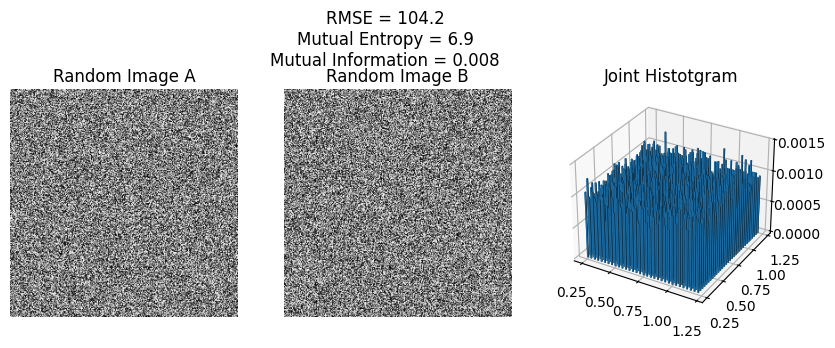

In [12]:
# plots
fig = plt.figure(figsize=(10,4)) 
axs0 = fig.add_subplot(1, 3, 1)
axs1 = fig.add_subplot(1, 3, 2)
axs2 = fig.add_subplot(1, 3, 3,projection='3d')

imgplot = axs0.imshow(A,cmap='gray')
axs0.set_title("Random Image A",fontsize=12)
axs0.set_axis_off()
imgplot = axs1.imshow(B,cmap='gray')
axs1.set_title("Random Image B",fontsize=12)
axs1.set_axis_off()
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0
# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.01 * np.ones_like(zpos)
dz = Hjoint.ravel()
axs2.bar3d(xpos, ypos, zpos, dx, dy, dz)
axs2.set_title("Joint Histotgram",fontsize=12)

fig.suptitle("RMSE = " +"{:.1f}".format(rmse)+"\n"+"Mutual Entropy = " + "{:.1f}".format(jointEntropy) +"\n"+"Mutual Information = " + "{:.3f}".format(MI)) # or plt.suptitle('Main title')


Otteniamo un valore molto basso della mutua informazione (vicino allo zero), visto che le immagini sono incorrelate. Il valore esatto dipenderà dal generatore di numeri casuali. L'istogramma è "piatto" in quanto l'altezza di tutte le colonne è la stessa a meno delle variazioni casuali. Il valore di RMSE dipende dal livello di rumore. 

Creiamo due immagini identiche (schacchiera)

In [14]:
# equal images
def checkerboard(shape):
    import cv2
    c = np.indices((8,8)).sum(axis=0) % 2 # 8x8 checkerboard
    return cv2.resize(np.array(c, dtype='uint16'),(shape,shape),interpolation=cv2.INTER_NEAREST)

A = maxS*checkerboard(dim)
B = maxS*checkerboard(dim)

Ripetiamo i calcoli precedenti di RMSE e mutua informazione

Text(0.5, 0.98, 'RMSE = 0.0\nMutual Entropy = 0.7\nMutual Information = 0.693')

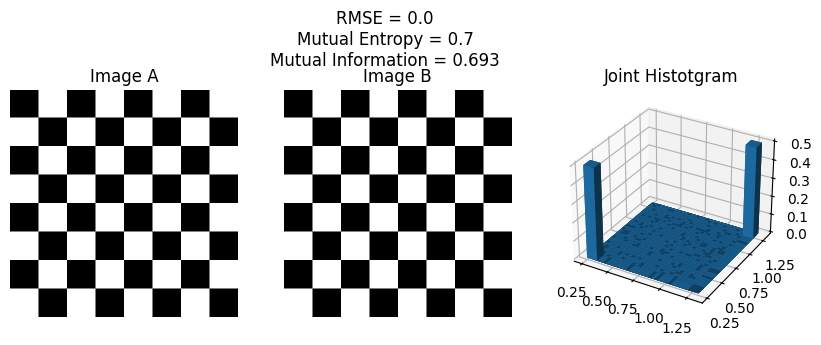

In [16]:
# calculate joint histogram
[Hjoint ,xedges, yedges]=np.histogram2d(np.reshape(A,dim*dim),np.reshape(B,dim*dim),bins)
Hjoint = Hjoint/(dim*dim)
xedges=xedges/dim
yedges=yedges/dim


# calculate mutual/joint entropy
Hjoint1 = np.reshape(Hjoint,bins*bins)
nz = np.where(Hjoint1 !=0)
jointEntropy = - np.sum(np.log(Hjoint1[nz])*Hjoint1[nz])

# calculate RMSE
rmse = np.sqrt(mean_squared_error(np.reshape(A,dim*dim),np.reshape(B,dim*dim)))

# calculate Mutual Information
[HA,edges] = np.histogram(np.reshape(A,dim*dim),bins)
HA=HA/(dim*dim)
[HB, edges] = np.histogram(np.reshape(B,dim*dim),bins)
HB=HB/(dim*dim)
nz = np.where(HA !=0)
AEntropy = -np.sum(np.log(HA[nz])*HA[nz])
nz = np.where(HB !=0)
BEntropy= -np.sum(np.log(HB[nz])*HA[nz])
MI = AEntropy + BEntropy -jointEntropy  

# plots
fig = plt.figure(figsize=(10,4)) 
axs0 = fig.add_subplot(1, 3, 1)
axs1 = fig.add_subplot(1, 3, 2)
axs2 = fig.add_subplot(1, 3, 3,projection='3d')


imgplot = axs0.imshow(A,cmap='gray')
axs0.set_title("Image A",fontsize=12)
axs0.set_axis_off()
imgplot = axs1.imshow(B,cmap='gray')
axs1.set_title("Image B",fontsize=12)
axs1.set_axis_off()
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0
# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.1 * np.ones_like(zpos)
dz = Hjoint.ravel()
axs2.bar3d(xpos, ypos, zpos, dx, dy, dz)
axs2.set_title("Joint Histotgram",fontsize=12)

fig.suptitle("RMSE = " +"{:.1f}".format(rmse)+"\n"+"Mutual Entropy = " + "{:.1f}".format(jointEntropy) +"\n"+"Mutual Information = " + "{:.3f}".format(MI)) # or plt.suptitle('Main title')


Per due immagini uguali otteniamo ovviamente RMSE=0. La mutua informazione è alta (il valore esatto dipende dalle caratteristiche dell'immagine come dimensione, profondità e livelli di grigio usati).   

Ruotiamo una delle due immagini a schacchiera per ottenere due immagini complementari (bianco - nero per tutti i pixel)

In [17]:
# complementary images
A = maxS*checkerboard(dim)
B = maxS*checkerboard(dim)

import cv2
B = cv2.rotate(B, cv2.ROTATE_90_COUNTERCLOCKWISE)

Ripetiamo i calcoli precedenti di RMSE e mutua informazione

Text(0.5, 0.98, 'RMSE = 255.0\nMutual Entropy = 0.7\nMutual Information = 0.693')

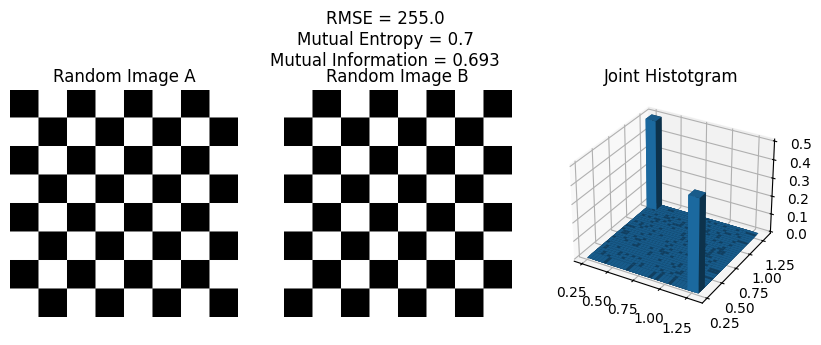

In [18]:
# calculate joint histogram
[Hjoint ,xedges, yedges]=np.histogram2d(np.reshape(A,dim*dim),np.reshape(B,dim*dim),bins)
Hjoint = Hjoint/(dim*dim)
xedges=xedges/dim
yedges=yedges/dim


# calculate mutual/joint entropy
Hjoint1 = np.reshape(Hjoint,bins*bins)
nz = np.where(Hjoint1 !=0)
jointEntropy = - np.sum(np.log(Hjoint1[nz])*Hjoint1[nz])

# calculate RMSE
rmse = np.sqrt(mean_squared_error(np.reshape(A,dim*dim),np.reshape(B,dim*dim)))

# calculate Mutual Information
[HA,edges] = np.histogram(np.reshape(A,dim*dim),bins)
HA=HA/(dim*dim)
[HB, edges] = np.histogram(np.reshape(B,dim*dim),bins)
HB=HB/(dim*dim)
nz = np.where(HA !=0)
AEntropy = -np.sum(np.log(HA[nz])*HA[nz])
nz = np.where(HB !=0)
BEntropy= -np.sum(np.log(HB[nz])*HA[nz])
MI = AEntropy + BEntropy -jointEntropy  

# plots
fig = plt.figure(figsize=(10,4)) 
axs0 = fig.add_subplot(1, 3, 1)
axs1 = fig.add_subplot(1, 3, 2)
axs2 = fig.add_subplot(1, 3, 3,projection='3d')


imgplot = axs0.imshow(A,cmap='gray')
axs0.set_title("Random Image A",fontsize=12)
axs0.set_axis_off()
imgplot = axs1.imshow(B,cmap='gray')
axs1.set_title("Random Image B",fontsize=12)
axs1.set_axis_off()
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0
# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.1 * np.ones_like(zpos)
dz = Hjoint.ravel()
axs2.bar3d(xpos, ypos, zpos, dx, dy, dz)
axs2.set_title("Joint Histotgram",fontsize=12)

fig.suptitle("RMSE = " +"{:.1f}".format(rmse)+"\n"+"Mutual Entropy = " + "{:.1f}".format(jointEntropy) +"\n"+"Mutual Information = " + "{:.3f}".format(MI)) # or plt.suptitle('Main title')


Il valore di RMSE diventa massimo (l'RMSE "vede" la differenza di segnale). IL valore di MI è lo stesso del caso precedente, cambia la posizione delle colonne dell'istogramma ma questo non cambia il valore dell'entropia mutua. La MI "vede" l'informazione che una immagine fornisce rispetto all'altra, nel caso precedente il valore di un pixel di A predice il valore di un pixel di B con la regola pB=pA, in questo con la regola pB=not(pA). In ogni caso la predizione è perfetta e la MI è alta.    

Transliamo una delle due immagini in modo da avere tutte le possibili coppie di valori (4) nell'istogramma mutuo.

Text(0.5, 0.98, 'RMSE = 127.3\nMutual Entropy = 1.3\nMutual Information = 0.132')

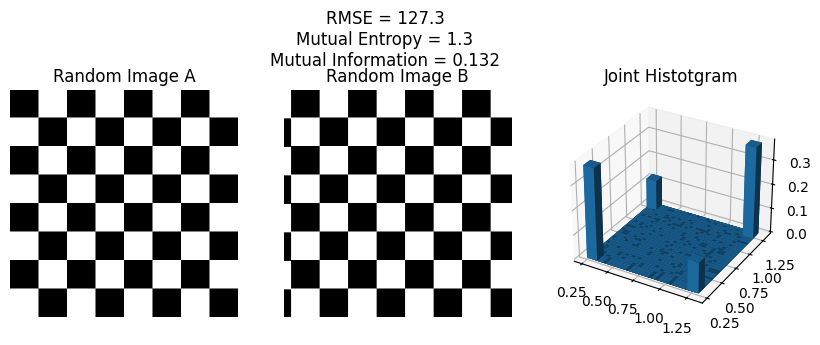

In [19]:
# translated images

A = maxS*checkerboard(dim)
B = maxS*checkerboard(dim)
B = np.roll(B, (0,8))

# calculate joint histogram
[Hjoint ,xedges, yedges]=np.histogram2d(np.reshape(A,dim*dim),np.reshape(B,dim*dim),bins)
Hjoint = Hjoint/(dim*dim)
xedges=xedges/dim
yedges=yedges/dim


# calculate mutual/joint entropy
Hjoint1 = np.reshape(Hjoint,bins*bins)
nz = np.where(Hjoint1 !=0)
jointEntropy = - np.sum(np.log(Hjoint1[nz])*Hjoint1[nz])

# calculate RMSE
rmse = np.sqrt(mean_squared_error(np.reshape(A,dim*dim),np.reshape(B,dim*dim)))

# calculate Mutual Information
[HA,edges] = np.histogram(np.reshape(A,dim*dim),bins)
HA=HA/(dim*dim)
[HB, edges] = np.histogram(np.reshape(B,dim*dim),bins)
HB=HB/(dim*dim)
nz = np.where(HA !=0)
AEntropy = -np.sum(np.log(HA[nz])*HA[nz])
nz = np.where(HB !=0)
BEntropy= -np.sum(np.log(HB[nz])*HA[nz])
MI = AEntropy + BEntropy -jointEntropy  

# plots
fig = plt.figure(figsize=(10,4)) 
axs0 = fig.add_subplot(1, 3, 1)
axs1 = fig.add_subplot(1, 3, 2)
axs2 = fig.add_subplot(1, 3, 3,projection='3d')


imgplot = axs0.imshow(A,cmap='gray')
axs0.set_title("Random Image A",fontsize=12)
axs0.set_axis_off()
imgplot = axs1.imshow(B,cmap='gray')
axs1.set_title("Random Image B",fontsize=12)
axs1.set_axis_off()
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0
# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.1 * np.ones_like(zpos)
dz = Hjoint.ravel()
axs2.bar3d(xpos, ypos, zpos, dx, dy, dz)
axs2.set_title("Joint Histotgram",fontsize=12)

fig.suptitle("RMSE = " +"{:.1f}".format(rmse)+"\n"+"Mutual Entropy = " + "{:.1f}".format(jointEntropy) +"\n"+"Mutual Information = " + "{:.3f}".format(MI)) # or plt.suptitle('Main title')



Il valore di MI scende in quanto si creano più colonne nell'istogramma e quindi più basse. Per ottenere il valore massimo della MI dovremmo translare B in modo da ritrovare l'allineamento, quindi massimizzare MI corrisponde a registrare le immagini. Notiamo che, avendo shiftato B di 8 pixel, uno shift di -8 o di +24 danno il valore di MI massimo, perchè per la MI immagini uguali o complementari sono equivalenti. Si provi a variare il valore delo shift  

Ripetiamo l'esempio precedente in presenza di rumore

Text(0.5, 0.98, 'RMSE = 133.5\nMutual Entropy = 5.7\nMutual Information = 0.135')

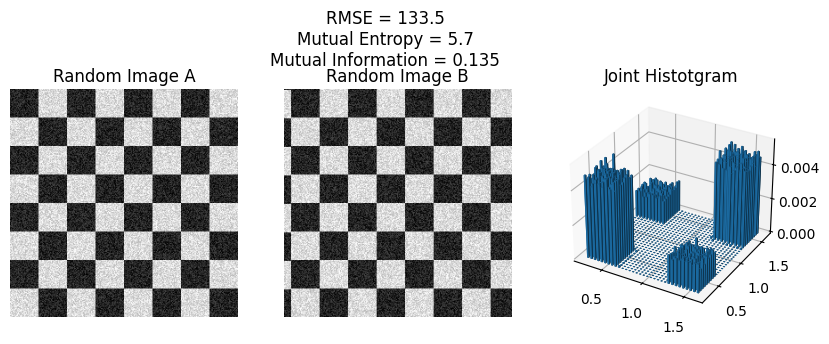

In [24]:
# translated images + noise
SD=100
A = maxS*checkerboard(dim) +SD*np.random.rand(dim,dim)
B = maxS*checkerboard(dim) +SD*np.random.rand(dim,dim)
B = np.roll(B, (0,8))

# calculate joint histogram
[Hjoint ,xedges, yedges]=np.histogram2d(np.reshape(A,dim*dim),np.reshape(B,dim*dim),bins)
Hjoint = Hjoint/(dim*dim)
xedges=xedges/dim
yedges=yedges/dim


# calculate mutual/joint entropy
Hjoint1 = np.reshape(Hjoint,bins*bins)
nz = np.where(Hjoint1 !=0)
jointEntropy = - np.sum(np.log(Hjoint1[nz])*Hjoint1[nz])

# calculate RMSE
rmse = np.sqrt(mean_squared_error(np.reshape(A,dim*dim),np.reshape(B,dim*dim)))

# calculate Mutual Information
[HA,edges] = np.histogram(np.reshape(A,dim*dim),bins)
HA=HA/(dim*dim)
[HB, edges] = np.histogram(np.reshape(B,dim*dim),bins)
HB=HB/(dim*dim)
nz = np.where(HA !=0)
AEntropy = -np.sum(np.log(HA[nz])*HA[nz])
nz = np.where(HB !=0)
BEntropy= -np.sum(np.log(HB[nz])*HA[nz])
MI = AEntropy + BEntropy -jointEntropy  

# plots
fig = plt.figure(figsize=(10,4)) 
axs0 = fig.add_subplot(1, 3, 1)
axs1 = fig.add_subplot(1, 3, 2)
axs2 = fig.add_subplot(1, 3, 3,projection='3d')


imgplot = axs0.imshow(A,cmap='gray')
axs0.set_title("Random Image A",fontsize=12)
axs0.set_axis_off()
imgplot = axs1.imshow(B,cmap='gray')
axs1.set_title("Random Image B",fontsize=12)
axs1.set_axis_off()
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25, yedges[:-1] + 0.25, indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0
# Construct arrays with the dimensions for the 16 bars.
dx = dy = 0.02 * np.ones_like(zpos)
dz = Hjoint.ravel()
axs2.bar3d(xpos, ypos, zpos, dx, dy, dz)
axs2.set_title("Joint Histotgram",fontsize=12)

fig.suptitle("RMSE = " +"{:.1f}".format(rmse)+"\n"+"Mutual Entropy = " + "{:.1f}".format(jointEntropy) +"\n"+"Mutual Information = " + "{:.3f}".format(MI)) # or plt.suptitle('Main title')



Il rumore "allarga" le colonne, similmente a quanto succede nell'istogramma di una singola immagine, ma il valore di MI resta molto simile a quello del caso precedente. Fino a quando le colonne non si sovrappongono la MI è una metrica "robusta" per la registrazione. Si provi ad aumnetare il valore di SD 